In [ ]:
!pip install optuna-integration[sklearn]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.1/99.1 kB 6.7 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix,make_scorer
import xgboost as xgb
import lightgbm as lgb
import optuna
from optuna.samplers import TPESampler
from optuna.logging import set_verbosity
import warnings

warnings.filterwarnings('ignore')
set_verbosity(optuna.logging.WARNING)

# Exploratory Data Analysis

In [ ]:
df = pd.read_csv('abb.csv')

In [ ]:
df.describe()

,propertyid,attrition,latitude,longitude,bedrooms,bathrooms,averagedailyrateusd,rating_overall,rating_communication,rating_accuracy,...,reservationdays4,reservationdays5,reservationdays6,reservationdays7,reservationdays8,reservationdays9,reservationdays10,reservationdays11,reservationdays12,nmon
count,5.247000e+03,5247.000000,5247.000000,5247.000000,5247.000000,5247.000000,5247.000000,5247.000000,5247.000000,5247.000000,...,5247.000000,5247.000000,5247.000000,5247.000000,5247.000000,5247.000000,5247.000000,5247.000000,5247.000000,5247.000000
mean,8.265740e+06,0.234610,37.775880,-122.365562,1.365352,1.284829,199.841965,95.175719,9.858967,9.749952,...,13.592370,16.011912,16.916238,18.457182,18.379296,16.399180,16.202910,12.841846,12.411171,27.324185
std,5.441294e+06,0.423795,0.140524,0.170301,0.986819,0.662294,211.686224,4.948033,0.388952,0.522454,...,9.056921,9.059657,8.759563,8.923064,8.691217,8.671357,8.691474,7.988808,8.447598,9.888991
min,9.580000e+02,0.000000,37.110317,-122.970420,0.000000,0.000000,10.000000,40.000000,4.000000,2.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,12.000000
25%,3.261666e+06,0.000000,37.735798,-122.447375,1.000000,1.000000,91.235001,94.000000,10.000000,10.000000,...,5.666666,8.666667,10.000000,11.666667,12.000000,9.500000,9.250000,6.250000,5.333334,19.000000
50%,7.972559e+06,0.000000,37.777298,-122.411730,1.000000,1.000000,139.480000,96.000000,10.000000,10.000000,...,13.500000,16.500000,18.000000,20.000000,19.750000,17.000000,16.500000,12.666667,12.000000,26.000000
75%,1.328322e+07,0.000000,37.847954,-122.266010,2.000000,1.000000,226.579995,98.000000,10.000000,10.000000,...,21.333334,24.000000,24.500000,26.000000,26.000000,24.000000,23.583333,19.000000,19.000000,36.000000
max,1.813962e+07,1.000000,38.309280,-121.595760,11.000000,8.000000,4014.460000,100.000000,10.000000,10.000000,...,30.000000,31.000000,30.000000,31.000000,31.000000,30.000000,31.000000,30.000000,31.000000,44.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5247 entries, 0 to 5246
Data columns (total 27 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   propertyid            5247 non-null   int64  
 1   attrition             5247 non-null   int64  
 2   latitude              5247 non-null   float64
 3   longitude             5247 non-null   float64
 4   bedrooms              5247 non-null   int64  
 5   bathrooms             5247 non-null   float64
 6   averagedailyrateusd   5247 non-null   float64
 7   rating_overall        5247 non-null   int64  
 8   rating_communication  5247 non-null   int64  
 9   rating_accuracy       5247 non-null   int64  
 10  rating_cleanliness    5247 non-null   int64  
 11  rating_checkin        5247 non-null   int64  
 12  rating_location       5247 non-null   int64  
 13  rating_value          5247 non-null   int64  
 14  reservationdays1      5247 non-null   float64
 15  reservationdays2     

In [ ]:
reserve = 'reservationdays'
reserve_list = []
for i in range(1,13):
  reserve_list.append(reserve+str(i))
df['total_reservationdays']=df[reserve_list].sum(axis=1)
df.drop(reserve_list,axis=1,inplace=True)

# --- NEW FEATURE ENGINEERING ---
# 1. Reservation Density/Loyalty (total reservations per month listed)
df['reservation_density'] = df['total_reservationdays'] / df['nmon']

# 2. Rating Dispersion (standard deviation of all rating columns)
rating_cols = ['rating_communication', 'rating_accuracy', 'rating_cleanliness',
               'rating_checkin', 'rating_location', 'rating_value']
df['rating_std'] = df[rating_cols].std(axis=1)

df.head()

,propertyid,attrition,latitude,longitude,bedrooms,bathrooms,averagedailyrateusd,rating_overall,rating_communication,rating_accuracy,rating_cleanliness,rating_checkin,rating_location,rating_value,nmon,total_reservationdays,reservation_density,rating_std
0,6091945,0,37.724739,-122.45676,1,1.0,100.10000,90,10,10,9,10,10,10,18,9.500000,0.527778,0.408248
1,7840421,1,37.847099,-122.48069,1,1.0,533.35999,89,10,9,9,9,10,9,23,70.000000,3.043478,0.516398
2,14357670,0,37.500595,-122.26466,1,1.0,158.63000,99,10,10,10,10,10,10,20,289.500000,14.475000,0.000000
3,6132191,0,37.796326,-122.41190,3,3.0,576.65002,98,10,10,10,10,10,10,35,86.500001,2.471429,0.000000
4,8249336,0,37.985527,-122.57745,1,1.0,134.53000,98,10,10,10,10,10,10,29,262.500002,9.051724,0.000000


In [ ]:
df['totalRevenue']=df['total_reservationdays']*df['averagedailyrateusd']
df['profit'] = 0.15*df['totalRevenue']


attrition
0    4016
1    1231
Name: count, dtype: int64


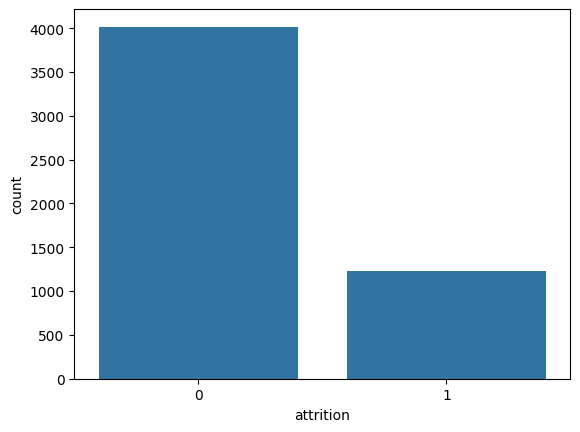

In [ ]:
sns.countplot(data=df,x='attrition')
print(df['attrition'].value_counts())

<Axes: >

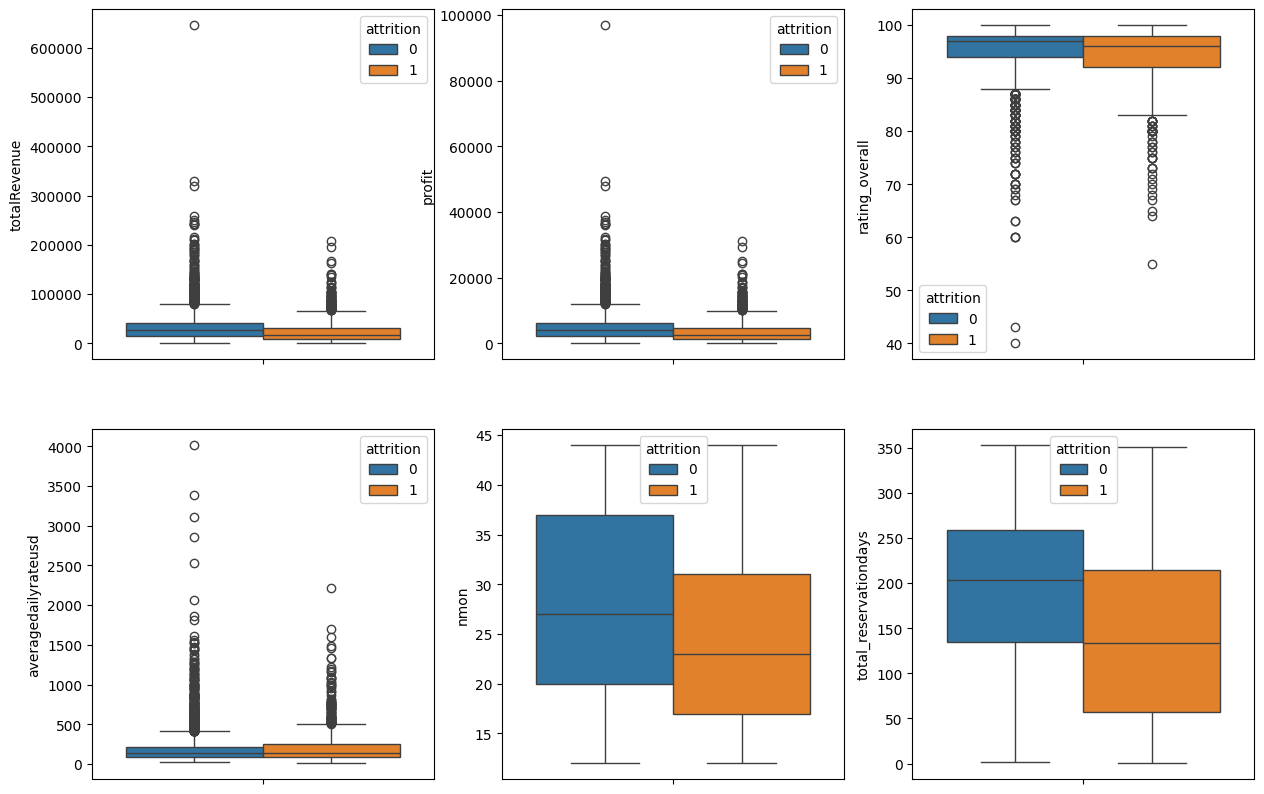

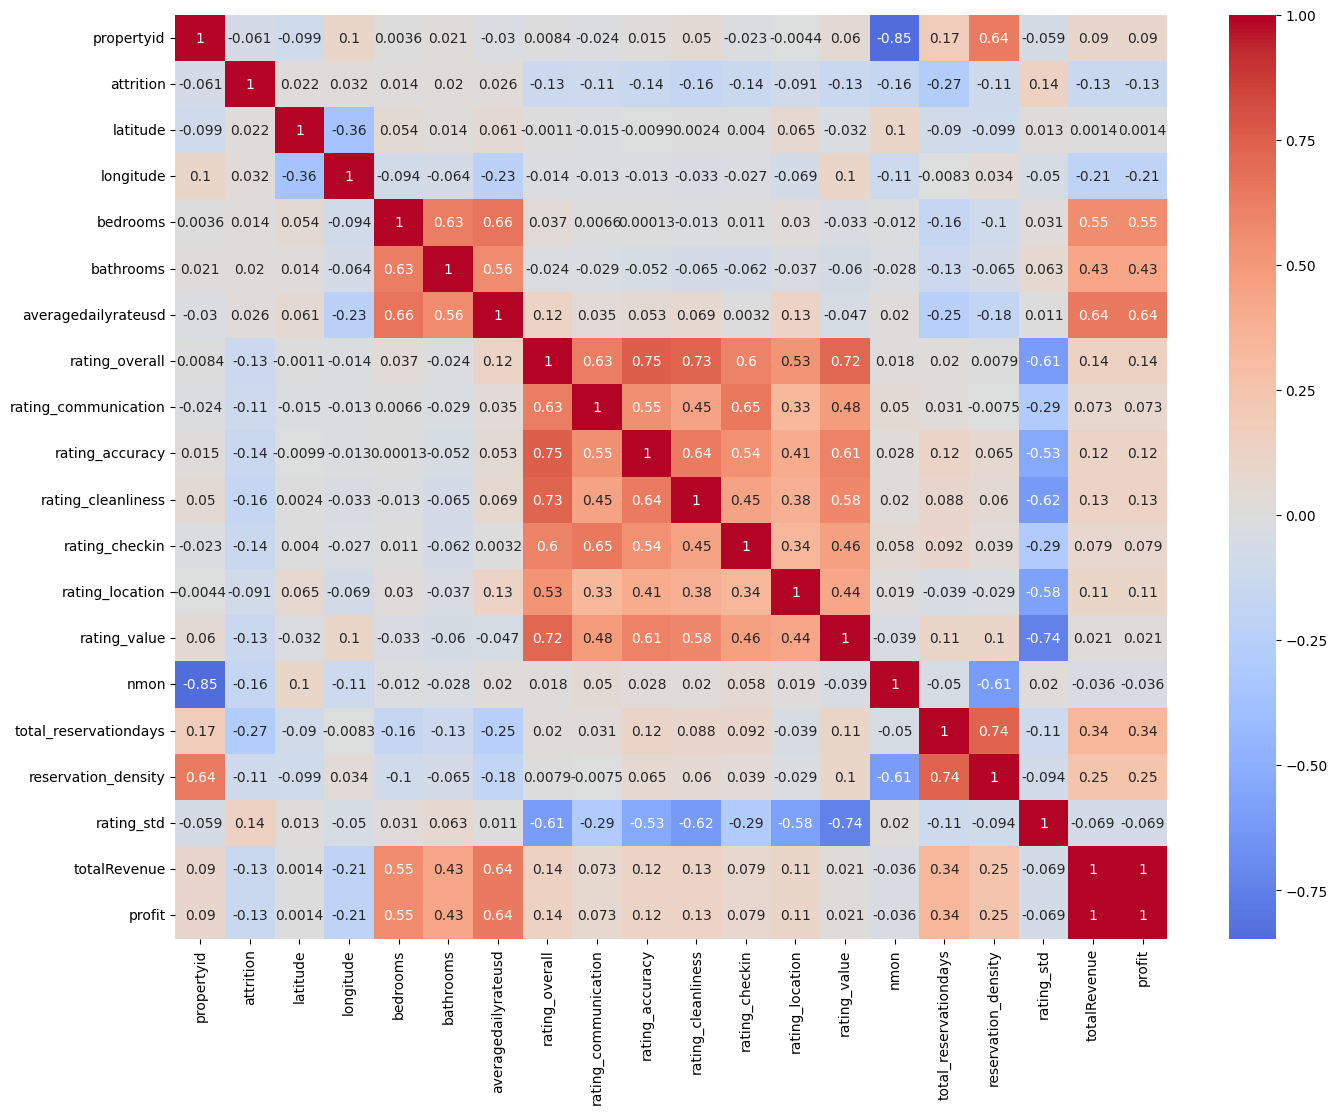

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
features = ['totalRevenue', 'profit', 'rating_overall',
            'averagedailyrateusd', 'nmon', 'total_reservationdays']
for i, feature in enumerate(features):
    sns.boxplot(data=df, y=feature, hue='attrition', ax=axes[i//3, i%3])

# 3. Correlation heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', center=0)




<Axes: xlabel='longitude', ylabel='latitude'>

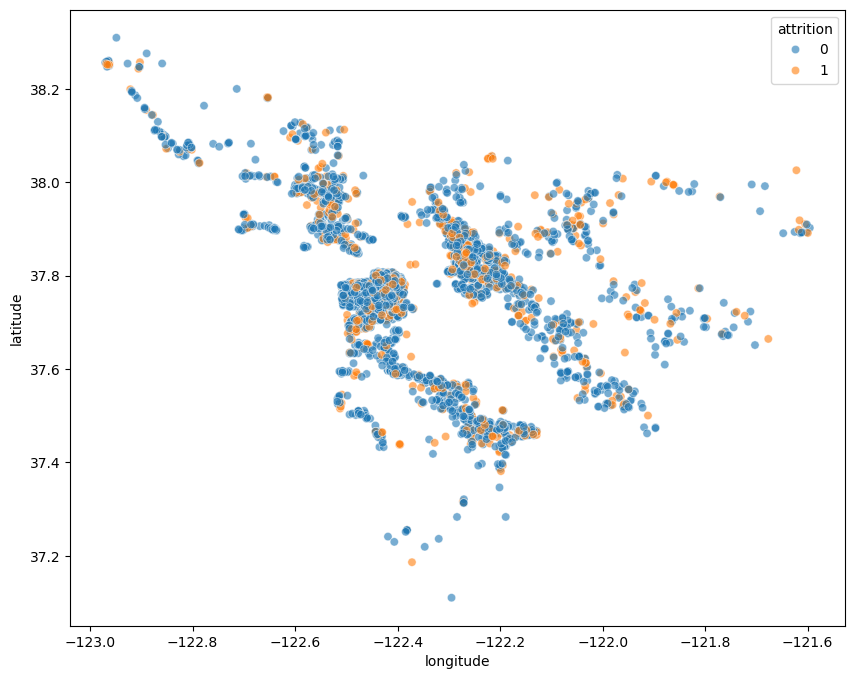

In [ ]:
# 4. Geographic scatter
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df, x='longitude', y='latitude',
                hue='attrition', alpha=0.6)

<Axes: >

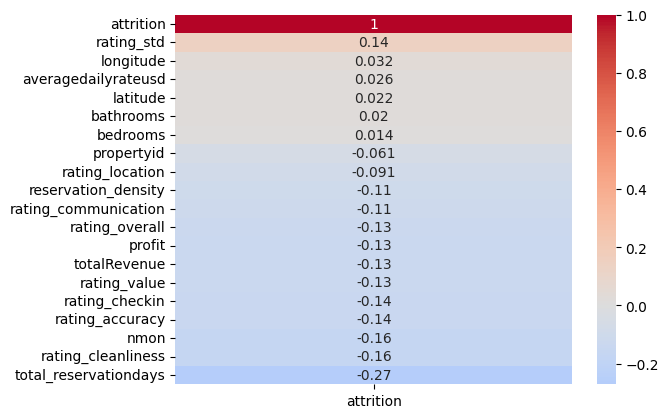

In [ ]:
# 5. Feature correlations with target
target_corr = df.corr()['attrition'].sort_values(ascending=False)

# Reshape the Series to a DataFrame with a single column for heatmap
sns.heatmap(pd.DataFrame(target_corr), annot=True, cmap='coolwarm', center=0)

# Load and Preprocessing for Train Data

In [ ]:
df_train = pd.read_csv('abb.csv')

In [ ]:
df_train = pd.read_csv('abb.csv') # Reload df_train to ensure original columns are present
reserve = 'reservationdays'
reserve_list = []
for i in range(1,13):
    reserve_list.append(reserve+str(i))
df_train['total_reservationdays']=df_train[reserve_list].sum(axis=1)
df_train.drop(reserve_list,axis=1,inplace=True)

# --- NEW FEATURE ENGINEERING (added to df_train) ---
# 1. Reservation Density/Loyalty (total reservations per month listed)
df_train['reservation_density'] = df_train['total_reservationdays'] / df_train['nmon']

# 2. Rating Dispersion (standard deviation of all rating columns)
rating_cols = ['rating_communication', 'rating_accuracy', 'rating_cleanliness',
               'rating_checkin', 'rating_location', 'rating_value']
df_train['rating_std'] = df_train[rating_cols].std(axis=1)
# -----------------------------------------------------

df_train.head()

,propertyid,attrition,latitude,longitude,bedrooms,bathrooms,averagedailyrateusd,rating_overall,rating_communication,rating_accuracy,rating_cleanliness,rating_checkin,rating_location,rating_value,nmon,total_reservationdays,reservation_density,rating_std
0,6091945,0,37.724739,-122.45676,1,1.0,100.10000,90,10,10,9,10,10,10,18,9.500000,0.527778,0.408248
1,7840421,1,37.847099,-122.48069,1,1.0,533.35999,89,10,9,9,9,10,9,23,70.000000,3.043478,0.516398
2,14357670,0,37.500595,-122.26466,1,1.0,158.63000,99,10,10,10,10,10,10,20,289.500000,14.475000,0.000000
3,6132191,0,37.796326,-122.41190,3,3.0,576.65002,98,10,10,10,10,10,10,35,86.500001,2.471429,0.000000
4,8249336,0,37.985527,-122.57745,1,1.0,134.53000,98,10,10,10,10,10,10,29,262.500002,9.051724,0.000000


In [ ]:
# ============================================
# STEP 1: Data Preparation
# ============================================

X = df_train.drop(['propertyid', 'attrition'], axis=1)
y = df_train['attrition']

# Split: 80% train, 20% test (holdout for final evaluation)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

# Calculate expected profits
annual_revenue_train = X_train['averagedailyrateusd'] * X_train['total_reservationdays']
expected_profit_train = 0.15 * annual_revenue_train

annual_revenue_test = X_test['averagedailyrateusd'] * X_test['total_reservationdays']
expected_profit_test = 0.15 * annual_revenue_test

print(f"Training set size: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Test set size: {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")
print(f"Class distribution - Train: {y_train.value_counts(normalize=True).to_dict()}")
print(f"Class distribution - Test: {y_test.value_counts(normalize=True).to_dict()}")

Training set size: 4197 (80.0%)
Test set size: 1050 (20.0%)者に説明するメッセージ。
Class distribution - Train: {0: 0.765308553728854, 1: 0.23469144627114605}
Class distribution - Test: {0: 0.7657142857142857, 1: 0.2342857142857143}


## Custom Profit Scoring Function to Optimize

The Decision Rule:

Give gift if: EV(Give Gift) > EV(No Gift)

EV(Give Gift) = Profit - $1,000

EV(No Gift) = (1 - p) × Profit

Give gift when:

Profit - $1,000 > (1 - p) × Profit

Profit - $1,000 > Profit - p × Profit

-$1,000 > -p × Profit

$1,000 < p × Profit

p × Profit > $1,000

In [ ]:
# ============================================
# STEP 2: Profit Scoring Function
# ============================================
retention_cost = 1000
def profit_score(y_true, y_gift, sample_weight=None):
    """
    Custom scoring function that calculates profit

    Parameters:
    - y_true: actual attrition labels
    - y_gift: predicted gift labels (after threshold)
    - sample_weight: expected profit for each property

    Returns: Total profit from retention strategy
    """

    if sample_weight is None:
        raise ValueError("sample_weight (expected profit) must be provided!")


    y_true = np.array(y_true)
    y_gift = np.array(y_gift)
    sample_weight = np.array(sample_weight)



    # Calculate profit for each property
    total_profit = 0

    for i in range(len(y_true)):
        actual_attrition = y_true[i]
        predicted_gift_allotment = y_gift[i]
        expected_profit_if_retained = sample_weight[i]

        if predicted_gift_allotment == 1:
            # We give the gift (predict they will leave)
            if actual_attrition == 1:
                # TRUE POSITIVE: They would leave, we retain them
                total_profit += expected_profit_if_retained - retention_cost
            else:
                # FALSE POSITIVE: They would stay, wasted gift
                total_profit += expected_profit_if_retained - retention_cost
        else:
            # We don't give gift (predict they will stay)
            if actual_attrition == 1:
                # FALSE NEGATIVE: They leave, we lose their profit
                total_profit += 0
            else:
                # TRUE NEGATIVE: They stay without gift
                total_profit += expected_profit_if_retained

    return total_profit



profit_scorer = make_scorer(profit_score, greater_is_better=True, needs_threshold=False)

# Cross Validation Objective function to maximize for Hyperparameter Tuning using Optuna

def profit_based_cv_score(model, X, y, expected_profits, cv=5):
    """Cross-validation with profit-based scoring"""
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)
    profits = []

    # Reset indices
    X_reset = X.reset_index(drop=True)
    y_reset = y.reset_index(drop=True)
    profits_reset = expected_profits.reset_index(drop=True)

    for train_idx, val_idx in skf.split(X_reset, y_reset):
        X_train_fold = X_reset.iloc[train_idx]
        X_val_fold = X_reset.iloc[val_idx]
        y_train_fold = y_reset.iloc[train_idx]
        y_val_fold = y_reset.iloc[val_idx]
        profit_val_fold = profits_reset.iloc[val_idx]

        # Train model
        model.fit(X_train_fold, y_train_fold)

        # Predict probabilities
        y_pred_proba = model.predict_proba(X_val_fold)[:, 1]

        # Apply profit-based decision rule
        expected_net_benefit = y_pred_proba * np.array(profit_val_fold) - retention_cost
        y_gift = (expected_net_benefit > 0).astype(int)

        # Calculate profit
        fold_profit = profit_score(
            np.array(y_val_fold),
            y_gift,
            sample_weight=np.array(profit_val_fold)
        )
        profits.append(fold_profit)

    return np.array(profits)

In [ ]:

# ============================================
# STEP 3: Optuna Optimization Functions
# ============================================

print(f"\n{'='*70}")
print("STARTING HYPERPARAMETER OPTIMIZATION")
print(f"{'='*70}")
print("Optimizing 4 models: XGBoost, LightGBM, RandomForest, LogisticRegression")
print("Optimization metric: Expected Profit")
print("This will take several minutes...\n")

# ------------------- XGBoost -------------------
def objective_xgb(trial):
    param = {
        'objective': 'binary:logistic',
        'eval_metric': 'auc',
        'tree_method': 'hist',
        'verbosity': 0,
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1, 5),
        'random_state': 42
    }

    model = xgb.XGBClassifier(**param)
    cv_profits = profit_based_cv_score(model, X_train, y_train, expected_profit_train, cv=5)
    return cv_profits.mean()

print("Optimizing XGBoost...")
study_xgb = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study_xgb.optimize(objective_xgb, n_trials=50, show_progress_bar=True)
print(f"✓ XGBoost Best CV Profit: ${study_xgb.best_value:,.0f}")

# ------------------- LightGBM -------------------
def objective_lgb(trial):
    param = {
        'objective': 'binary',
        'metric': 'auc',
        'verbosity': -1,
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1, 5),
        'random_state': 42
    }

    model = lgb.LGBMClassifier(**param)
    cv_profits = profit_based_cv_score(model, X_train, y_train, expected_profit_train, cv=5)
    return cv_profits.mean()

print("\nOptimizing LightGBM...")
study_lgb = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study_lgb.optimize(objective_lgb, n_trials=50, show_progress_bar=True)
print(f"✓ LightGBM Best CV Profit: ${study_lgb.best_value:,.0f}")

# ------------------- Random Forest -------------------
def objective_rf(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 5, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'class_weight': trial.suggest_categorical('class_weight', ['balanced', 'balanced_subsample', None]),
        'random_state': 42,
        'n_jobs': -1
    }

    model = RandomForestClassifier(**param)
    cv_profits = profit_based_cv_score(model, X_train, y_train, expected_profit_train, cv=5)
    return cv_profits.mean()

print("\nOptimizing Random Forest...")
study_rf = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study_rf.optimize(objective_rf, n_trials=50, show_progress_bar=True)
print(f"✓ Random Forest Best CV Profit: ${study_rf.best_value:,.0f}")

# ------------------- Logistic Regression -------------------
def objective_lr(trial):
    param = {
        'C': trial.suggest_float('C', 1e-3, 100, log=True),
        'penalty': trial.suggest_categorical('penalty', ['l1', 'l2']),
        'solver': 'liblinear',
        'class_weight': trial.suggest_categorical('class_weight', ['balanced', None]),
        'max_iter': 1000,
        'random_state': 42
    }

    model = LogisticRegression(**param)
    cv_profits = profit_based_cv_score(model, X_train_scaled, y_train, expected_profit_train, cv=5)
    return cv_profits.mean()

print("\nOptimizing Logistic Regression...")
study_lr = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study_lr.optimize(objective_lr, n_trials=30, show_progress_bar=True)

print(f"✓ Logistic Regression Best CV Profit: ${study_lr.best_value:,.0f}")


STARTING HYPERPARAMETER OPTIMIZATION
Optimizing 4 models: XGBoost, LightGBM, RandomForest, LogisticRegression
Optimization metric: Expected Profit
This will take several minutes...

Optimizing XGBoost...


  0%|          | 0/50 [00:00<?, ?it/s]

✓ XGBoost Best CV Profit: $3,477,778

Optimizing LightGBM...


  0%|          | 0/50 [00:00<?, ?it/s]

✓ LightGBM Best CV Profit: $3,477,690

Optimizing Random Forest...


  0%|          | 0/50 [00:00<?, ?it/s]

✓ Random Forest Best CV Profit: $3,479,870

Optimizing Logistic Regression...


  0%|          | 0/30 [00:00<?, ?it/s]

✓ Logistic Regression Best CV Profit: $3,452,202


In [ ]:
# Tuned XGBoost Model
print(f"Best params for XGBoost : {study_xgb.best_params}")
model_xgb = xgb.XGBClassifier(**study_xgb.best_params)

# Tuned LightGBM Model
print(f"Best params for LGBM : {study_lgb.best_params}")
model_lgb = lgb.LGBMClassifier(**study_lgb.best_params)

# Tuned RandomForest Classifier
print(f"Best params for RandomFores : {study_rf.best_params}")
model_rf = RandomForestClassifier(**study_rf.best_params)

# Tuned Logistic Regression Classifier
print(f"Best params for Logistic Regression : {study_lr.best_params}")
model_lr = LogisticRegression(**study_lr.best_params)


Best params for XGBoost : {'n_estimators': 267, 'learning_rate': 0.017288785584765334, 'max_depth': 10, 'min_child_weight': 1, 'subsample': 0.5389542454210272, 'colsample_bytree': 0.7753322618370093, 'gamma': 0.0004352370388218226, 'reg_alpha': 3.8801843825049476e-08, 'reg_lambda': 1.8879701461635063, 'scale_pos_weight': 1.0041008928390247}
Best params for LGBM : {'n_estimators': 336, 'learning_rate': 0.010206070557576998, 'max_depth': 6, 'num_leaves': 48, 'min_child_samples': 26, 'subsample': 0.9538323976412588, 'colsample_bytree': 0.97988537297271, 'reg_alpha': 8.476957030644504e-06, 'reg_lambda': 3.3316309468938505, 'scale_pos_weight': 1.0492446782597493}
Best params for RandomFores : {'n_estimators': 227, 'max_depth': 16, 'min_samples_split': 16, 'min_samples_leaf': 2, 'max_features': 'log2', 'class_weight': None}
Best params for Logistic Regression : {'C': 0.01991135647535838, 'penalty': 'l2', 'class_weight': None}


In [ ]:
# ============================================
# STEP 4: Train Final Models on Full Training Set
# ============================================

print(f"\n{'='*70}")
print("TRAINING FINAL MODELS ON FULL TRAINING SET")
print(f"{'='*70}")

# Train with best hyperparameters on ENTIRE training set
model_xgb = xgb.XGBClassifier(**study_xgb.best_params)
model_xgb.fit(X_train, y_train)

model_lgb = lgb.LGBMClassifier(**study_lgb.best_params)
model_lgb.fit(X_train, y_train)

model_rf = RandomForestClassifier(**study_rf.best_params)
model_rf.fit(X_train, y_train)

model_lr = LogisticRegression(**study_lr.best_params)
model_lr.fit(X_train_scaled, y_train)

print("✓ All models trained on full training set")



TRAINING FINAL MODELS ON FULL TRAINING SET
✓ All models trained on full training set


In [ ]:
# ============================================
# STEP 5: Evaluate on Test Set
# ============================================

print(f"\n{'='*70}")
print("TEST SET EVALUATION")
print(f"{'='*70}")

models = {
    'XGBoost': model_xgb,
    'LightGBM': model_lgb,
    'Random Forest': model_rf,
    'Logistic Regression': model_lr
}

results = []

for name, model in models.items():
    # Predictions
    if name == 'Logistic Regression':
      y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
      y_pred_proba = model.predict_proba(X_test)[:, 1]

    # Apply profit-based decision rule
    expected_net_benefit = y_pred_proba * expected_profit_test.values - retention_cost
    y_gift = (expected_net_benefit > 0).astype(int)

    # Calculate metrics
    test_profit = profit_score(y_test.values, y_gift, sample_weight=expected_profit_test.values)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    n_gifts = y_gift.sum()

    results.append({
        'Model': name,
        'Test_Profit': test_profit,
        'CV_Profit': study_xgb.best_value if name == 'XGBoost' else
                     study_lgb.best_value if name == 'LightGBM' else
                     study_rf.best_value if name == 'Random Forest' else
                     study_lr.best_value,
        'ROC_AUC': roc_auc,
        'N_Gifts': n_gifts,
        'Gift_Cost': n_gifts * retention_cost,
        'y_pred_proba': y_pred_proba,
        'y_gift': y_gift
    })

    print(f"\n{name}:")
    print(f"  Test Profit: ${test_profit:,.0f}")
    print(f"  ROC-AUC: {roc_auc:.3f}")
    print(f"  Gifts Given: {n_gifts}")
    print(f"  Total Gift Cost: ${n_gifts * retention_cost:,.0f}")

results_df = pd.DataFrame(results)



TEST SET EVALUATION

XGBoost:
  Test Profit: $4,367,391
  ROC-AUC: 0.792
  Gifts Given: 275
  Total Gift Cost: $275,000

LightGBM:
  Test Profit: $4,358,222
  ROC-AUC: 0.781
  Gifts Given: 307
  Total Gift Cost: $307,000

Random Forest:
  Test Profit: $4,384,634
  ROC-AUC: 0.791
  Gifts Given: 323
  Total Gift Cost: $323,000

Logistic Regression:
  Test Profit: $4,342,469
  ROC-AUC: 0.765
  Gifts Given: 297
  Total Gift Cost: $297,000


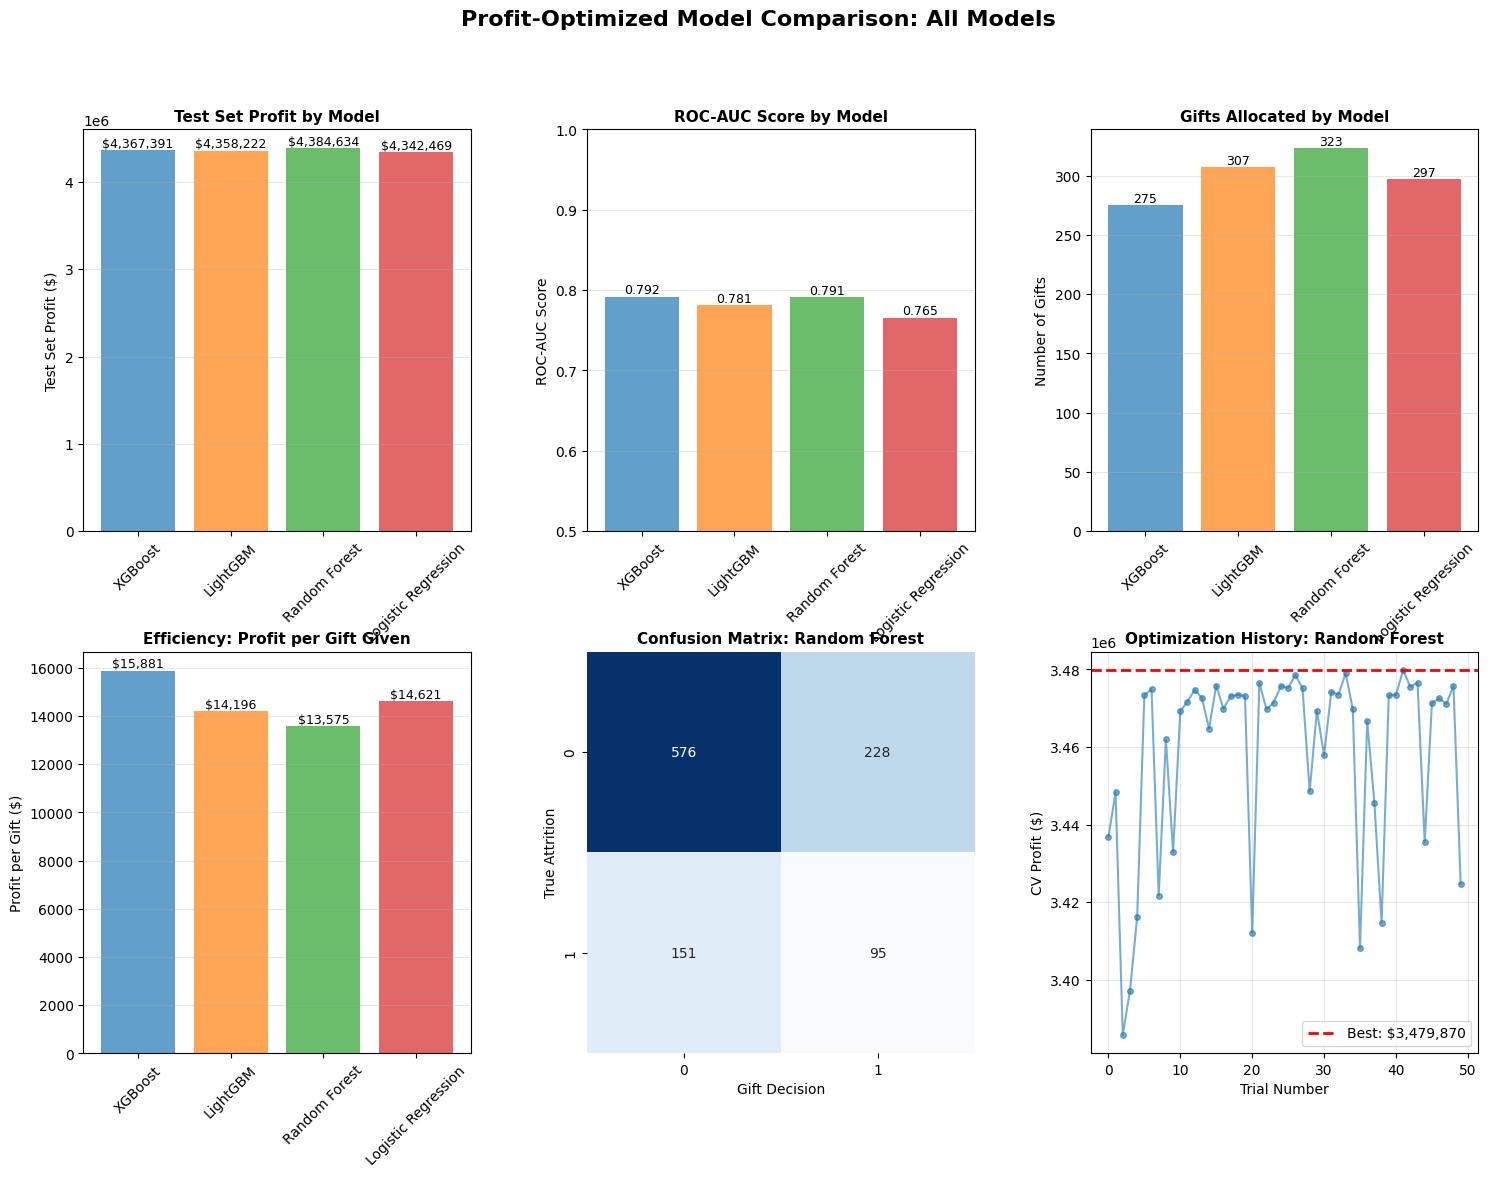

In [ ]:
# ============================================
# STEP 6: Comparison Visualizations
# ============================================

fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)

fig.suptitle('Profit-Optimized Model Comparison: All Models', fontsize=16, fontweight='bold')

# 1. Test Profit Comparison
ax1 = fig.add_subplot(gs[0, 0])
bars = ax1.bar(results_df['Model'], results_df['Test_Profit'],
               color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'], alpha=0.7)
ax1.set_ylabel('Test Set Profit ($)', fontsize=10)
ax1.set_title('Test Set Profit by Model', fontsize=11, fontweight='bold')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', alpha=0.3)

for i, (bar, val) in enumerate(zip(bars, results_df['Test_Profit'])):
    ax1.text(bar.get_x() + bar.get_width()/2, val, f'${val:,.0f}',
             ha='center', va='bottom', fontsize=9)


# 2. ROC-AUC Comparison
ax2 = fig.add_subplot(gs[0, 1])
bars = ax2.bar(results_df['Model'], results_df['ROC_AUC'],
               color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'], alpha=0.7)
ax2.set_ylabel('ROC-AUC Score', fontsize=10)
ax2.set_title('ROC-AUC Score by Model', fontsize=11, fontweight='bold')
ax2.tick_params(axis='x', rotation=45)
ax2.set_ylim(0.5, 1.0)
ax2.grid(axis='y', alpha=0.3)

for bar, val in zip(bars, results_df['ROC_AUC']):
    ax2.text(bar.get_x() + bar.get_width()/2, val, f'{val:.3f}',
             ha='center', va='bottom', fontsize=9)

# 3. Number of Gifts
ax3 = fig.add_subplot(gs[0, 2])
bars = ax3.bar(results_df['Model'], results_df['N_Gifts'],
               color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'], alpha=0.7)
ax3.set_ylabel('Number of Gifts', fontsize=10)
ax3.set_title('Gifts Allocated by Model', fontsize=11, fontweight='bold')
ax3.tick_params(axis='x', rotation=45)
ax3.grid(axis='y', alpha=0.3)

for bar, val in zip(bars, results_df['N_Gifts']):
    ax3.text(bar.get_x() + bar.get_width()/2, val, f'{int(val)}',
             ha='center', va='bottom', fontsize=9)

# 4. Profit per Gift
ax4 = fig.add_subplot(gs[1, 0])
profit_per_gift = results_df['Test_Profit'] / results_df['N_Gifts']
bars = ax4.bar(results_df['Model'], profit_per_gift,
               color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'], alpha=0.7)
ax4.set_ylabel('Profit per Gift ($)', fontsize=10)
ax4.set_title('Efficiency: Profit per Gift Given', fontsize=11, fontweight='bold')
ax4.tick_params(axis='x', rotation=45)
ax4.grid(axis='y', alpha=0.3)

for bar, val in zip(bars, profit_per_gift):
    ax4.text(bar.get_x() + bar.get_width()/2, val, f'${val:,.0f}',
             ha='center', va='bottom', fontsize=9)

# 5. Confusion Matrices (Best Model)
best_model_idx = results_df['Test_Profit'].idxmax()
best_model_name = results_df.loc[best_model_idx, 'Model']
best_y_gift = results_df.loc[best_model_idx, 'y_gift']

ax5 = fig.add_subplot(gs[1, 1])
cm = confusion_matrix(y_test, best_y_gift)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax5, cbar=False)
ax5.set_ylabel('True Attrition', fontsize=10)
ax5.set_xlabel('Gift Decision', fontsize=10)
ax5.set_title(f'Confusion Matrix: {best_model_name}', fontsize=11, fontweight='bold')

# 6. Optimization History (Best Model)
ax6 = fig.add_subplot(gs[1, 2])
if best_model_name == 'XGBoost':
    study = study_xgb
elif best_model_name == 'LightGBM':
    study = study_lgb
elif best_model_name == 'Random Forest':
    study = study_rf
else:
    study = study_lr

trials_df = study.trials_dataframe()
ax6.plot(trials_df['number'], trials_df['value'], 'o-', alpha=0.6, markersize=4)
ax6.axhline(y=study.best_value, color='red', linestyle='--',
            linewidth=2, label=f'Best: ${study.best_value:,.0f}')
ax6.set_xlabel('Trial Number', fontsize=10)
ax6.set_ylabel('CV Profit ($)', fontsize=10)
ax6.set_title(f'Optimization History: {best_model_name}', fontsize=11, fontweight='bold')
ax6.legend()
ax6.grid(alpha=0.3)

plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
# ============================================
# STEP 7: Summary Report
# ============================================

print(f"\n{'='*70}")
print("FINAL SUMMARY REPORT")
print(f"{'='*70}")

# Sort by test profit
results_summary = results_df.sort_values('Test_Profit', ascending=False)

print("\nModel Rankings (by Test Set Profit):")
print(results_summary[['Model', 'Test_Profit', 'CV_Profit', 'ROC_AUC', 'N_Gifts']].to_string(index=False))

best_model = results_summary.iloc[0]
print(f"\n{'='*70}")
print(f"🏆 BEST MODEL: {best_model['Model']}")
print(f"{'='*70}")
print(f"Test Profit: ${best_model['Test_Profit']:,.0f}")
print(f"CV Profit: ${best_model['CV_Profit']:,.0f}")
print(f"ROC-AUC: {best_model['ROC_AUC']:.3f}")
print(f"Gifts Allocated: {int(best_model['N_Gifts'])} properties")
print(f"Total Gift Cost: ${best_model['Gift_Cost']:,.0f}")
print(f"Profit per Gift: ${best_model['Test_Profit'] / best_model['N_Gifts']:,.0f}")

print(f"\n{'='*70}")
print("BEST HYPERPARAMETERS")
print(f"{'='*70}")
if best_model['Model'] == 'XGBoost':
    print(study_xgb.best_params)
elif best_model['Model'] == 'LightGBM':
    print(study_lgb.best_params)
elif best_model['Model'] == 'Random Forest':
    print(study_rf.best_params)
else:
    print(study_lr.best_params)

print(f"\n{'='*70}")
print("KEY INSIGHTS")
print(f"{'='*70}")
print(f"1. Best model improves profit by ${best_model['Test_Profit']:,.0f}")
print(f"2. Allocated {int(best_model['N_Gifts'])} gifts strategically")
print(f"3. Profit-optimization prioritizes high-value, at-risk properties")
print(f"4. Cross-validation ensures robust hyperparameter selection")
print(f"5. Model trained on full 80% training set maximizes learning")



FINAL SUMMARY REPORT

Model Rankings (by Test Set Profit):
              Model  Test_Profit    CV_Profit  ROC_AUC  N_Gifts
      Random Forest 4.384634e+06 3.479870e+06 0.791242      323
            XGBoost 4.367391e+06 3.477778e+06 0.791717      275
           LightGBM 4.358222e+06 3.477690e+06 0.781100      307
Logistic Regression 4.342469e+06 3.452202e+06 0.765441      297

🏆 BEST MODEL: Random Forest
Test Profit: $4,384,634
CV Profit: $3,479,870
ROC-AUC: 0.791
Gifts Allocated: 323 properties
Total Gift Cost: $323,000
Profit per Gift: $13,575

BEST HYPERPARAMETERS
{'n_estimators': 227, 'max_depth': 16, 'min_samples_split': 16, 'min_samples_leaf': 2, 'max_features': 'log2', 'class_weight': None}

KEY INSIGHTS
1. Best model improves profit by $4,384,634
2. Allocated 323 gifts strategically
3. Profit-optimization prioritizes high-value, at-risk properties
4. Cross-validation ensures robust hyperparameter selection
5. Model trained on full 80% training set maximizes learning


In [ ]:
# ============================================
# STEP 8: FINAL MODEL - TRAIN ON 100% OF DATA
# ============================================

print(f"\n{'='*70}")
print("STEP 8: TRAINING FINAL MODEL ON 100% OF DATA")
print(f"{'='*70}")
print(f"Best model selected: {best_model['Model']}")
print(f"Now training on ALL available data (100%) for deployment...")

# Get best hyperparameters
if best_model['Model'] == 'XGBoost':
    best_params = study_xgb.best_params
    final_model = xgb.XGBClassifier(**best_params)
elif best_model['Model'] == 'LightGBM':
    best_params = study_lgb.best_params
    final_model = lgb.LGBMClassifier(**best_params)
elif best_model['Model'] == 'Random Forest':
    best_params = study_rf.best_params
    final_model = RandomForestClassifier(**best_params)
else:
    best_params = study_lr.best_params
    final_model = LogisticRegression(**best_params)

# Prepare full dataset (100%)
X_full = df_train.drop(['propertyid', 'attrition'], axis=1)
y_full = df_train['attrition']


# Fit scaler on 100% of data
scaler_full = StandardScaler()
X_full_scaled = pd.DataFrame(
    scaler_full.fit_transform(X_full),
    columns=X_full.columns,
    index=X_full.index
)

# Train final model on 100% of data
if best_model['Model'] == 'Logistic Regression':
  final_model.fit(X_full_scaled, y_full)
else:
  final_model.fit(X_full, y_full)
print(f"✓ Final model {best_model['Model']}trained on {len(X_full)} samples (100% of training data)")



STEP 8: TRAINING FINAL MODEL ON 100% OF DATA
Best model selected: Random Forest
Now training on ALL available data (100%) for deployment...
✓ Final model Random Foresttrained on 5247 samples (100% of training data)


In [ ]:
# ============================================
# STEP 9: APPLY TO NEW DATA (abb_new.csv)
# ============================================

print(f"\n{'='*70}")
print("STEP 9: APPLYING MODEL TO NEW DATA (abb_new.csv)")
print(f"{'='*70}")

# Load new data
df_new = pd.read_csv('abb_new.csv')
print(f"Loaded abb_new.csv: {len(df_new)} properties")

reserve = 'reservationdays'
reserve_list = []
for i in range(1,13):
  reserve_list.append(reserve+str(i))
df_new['total_reservationdays']=df_new[reserve_list].sum(axis=1)
df_new.drop(reserve_list,axis=1,inplace=True)

# --- NEW FEATURE ENGINEERING ---
# 1. Reservation Density/Loyalty (total reservations per month listed)
df_new['reservation_density'] = df_new['total_reservationdays'] / df_new['nmon']

# 2. Rating Dispersion (standard deviation of all rating columns)
rating_cols = ['rating_communication', 'rating_accuracy', 'rating_cleanliness',
               'rating_checkin', 'rating_location', 'rating_value']
df_new['rating_std'] = df_new[rating_cols].std(axis=1)


# Prepare features (same preprocessing as training)
X_new = df_new.drop(['propertyid'], axis=1)

# Scale features using the scaler fitted on 100% training data
X_new_scaled = pd.DataFrame(
    scaler_full.transform(X_new),
    columns=X_new.columns,
    index=X_new.index
)

# Calculate expected profits for new data
annual_revenue_new = X_new['averagedailyrateusd'] * X_new['total_reservationdays']
expected_profit_new = 0.15 * annual_revenue_new

# Predict attrition probabilities
if best_model['Model'] == 'Logistic Regression':
  y_new_proba = final_model.predict_proba(X_new_scaled)[:, 1]
else:
  y_new_proba = final_model.predict_proba(X_new)[:, 1]

# Apply profit-based decision rule
expected_net_benefit_new = y_new_proba * expected_profit_new.values - retention_cost
gift_decision_new = (expected_net_benefit_new > 0).astype(int)

# Add gift column to original dataframe
df_new['gift'] = gift_decision_new
# df_new['attrition_probability'] = y_new_proba

# Save results
output_filename = 'abb_new__with_gifts_final.csv'
df_new.to_csv(output_filename, index=False)

print(f"\n{'='*70}")
print("DEPLOYMENT RESULTS")
print(f"{'='*70}")
print(f"Total properties in abb_new.csv: {len(df_new)}")
print(f"Properties receiving $1,000 gift: {gift_decision_new.sum()}")
print(f"Properties NOT receiving gift: {(gift_decision_new == 0).sum()}")
print(f"Total retention budget: ${gift_decision_new.sum() * retention_cost:,.0f}")

# Calculate expected benefit
expected_prevented_loss = (y_new_proba * expected_profit_new * gift_decision_new).sum()
total_gift_cost = gift_decision_new.sum() * retention_cost
expected_net_profit = expected_prevented_loss - total_gift_cost

print(f"\nExpected Financial Impact:")
print(f"  Expected losses prevented: ${expected_prevented_loss:,.0f}")
print(f"  Total gift cost: ${total_gift_cost:,.0f}")
print(f"  Expected net benefit: ${expected_net_profit:,.0f}")

print(f"\n✓ Results saved to: {output_filename}")


STEP 9: APPLYING MODEL TO NEW DATA (abb_new.csv)
Loaded abb_new.csv: 1312 properties

DEPLOYMENT RESULTS
Total properties in abb_new.csv: 1312
Properties receiving $1,000 gift: 366
Properties NOT receiving gift: 946
Total retention budget: $366,000

Expected Financial Impact:
  Expected losses prevented: $814,448
  Total gift cost: $366,000
  Expected net benefit: $448,448

✓ Results saved to: abb_new__with_gifts_final.csv
